# PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA

**Objective:** The objective of this assignment is to train Word2Vec models on textual data collected from IIT Jodhpur sources and analyze the semantic structure captured by the learned embeddings.


Found 'corpus.txt'! Loading data directly to save time...
Loaded 126 documents from corpus.txt

DATASET STATISTICS AFTER PREPROCESSING
Total Number of Documents: 126
Total Number of Tokens: 590588
Vocabulary Size: 31611
Average Tokens per Document: 4687.21


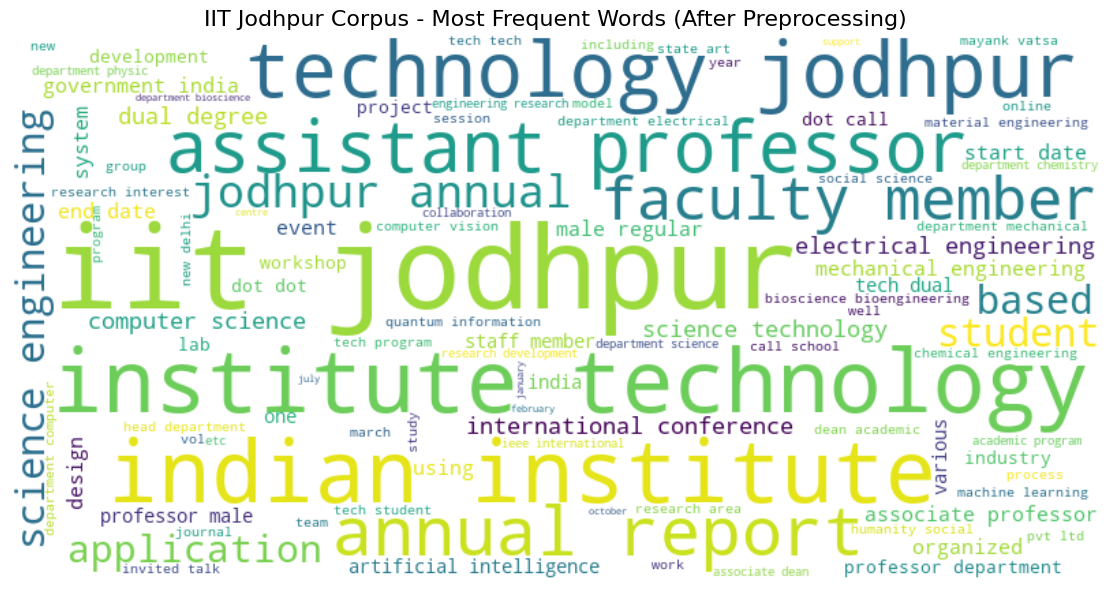

In [ ]:
# Load and clean the source text

import os
import re
import requests
from bs4 import BeautifulSoup
import PyPDF2
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import html

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

# Data Preprocessing Function
lemmatizer = WordNetLemmatizer()

# Stopwords
custom_stopwords = {
    'https', 'http', 'www', 'doi', 'org', 'issn', 'isbn', 'yes', 'rs', 'lakh', 'lakhs', 'may', 'will',
    'dr', 'kumar', 'singh', 'shri', 'sri', 'mr', 'ms', 'mrs', 'prof', 'prof',
    'page', 'site', 'web', 'click', 'link', 'email', 'contact', 'phone', 'address',
    'iitj'
}
all_stopwords = set(stopwords.words('english')).union(custom_stopwords)

def clean_text(text):
    # Text preprocessing with multiple cleaning steps
    # Decode HTML entities
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    # Remove special characters and punctuation, keep only alphabetic and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Collapse obvious OCR-style repeated characters
    text = re.sub(r'(.)\\1{2,}', r'\\1\\1', text)
    # Tokenize
    tokens = text.split()
    
    # Filter: remove stopwords, very short tokens, very long tokens, and OCR/noise patterns
    clean_tokens = []
    for w in tokens:
        lemma = lemmatizer.lemmatize(w)
        if len(lemma) <= 2 or len(lemma) >= 20:
            continue
        if lemma in all_stopwords:
            continue
        if re.search(r'(.)\\1{2,}', lemma):
            continue
        if len(set(lemma)) == 1:
            continue
        clean_tokens.append(lemma)
    
    return clean_tokens

all_tokens = []
clean_documents = []

# Scraping Logic
if os.path.exists(r'B23CM1062-A2\corpus.txt'):
    print("Found 'corpus.txt'! Loading data directly to save time...")
    with open(r'B23CM1062-A2\corpus.txt', 'r', encoding='utf-8') as f:

        count = 0
        for line in f:
            tokens = line.strip().split()
            if tokens and len(tokens) > 3:  # Only keep documents with at least 3 tokens
                clean_documents.append(tokens)
                all_tokens.extend(tokens)
                count += 1
        print(f"Loaded {count} documents from corpus.txt")
else:
    print("'corpus.txt' not found. Initiating web scraping and PDF extraction...")
    
    def get_text_from_url(url):
        """Extract clean text from URL"""
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            soup = BeautifulSoup(response.text, 'html.parser')
            
            # Remove script, style, and navigation elements
            for script in soup(["script", "style", "header", "footer", "nav"]):
                script.extract()
            
            # Extract text
            text = soup.get_text(separator=' ')
            return text
        except Exception as e:
            print(f"Failed to scrape {url}: {e}")
            return ""

    def get_text_from_pdf(pdf_path):
        """Extract clean text from PDF"""
        text = ""
        try:
            with open(pdf_path, 'rb') as file:
                reader = PyPDF2.PdfReader(file)
                for page_num, page in enumerate(reader.pages):
                    try:
                        extracted = page.extract_text()
                        if extracted:
                            text += extracted + " "
                    except Exception as e:
                        print(f"Failed to read page {page_num} from {pdf_path}: {e}")
        except Exception as e:
            print(f"Failed to read PDF {pdf_path}: {e}")
        return text

    urls_to_scrape = [
        "https://iitj.ac.in/", 
        "https://www.iitj.ac.in/main/en/recruitments",
        "https://www.iitj.ac.in/suraj/en/internship",
        "https://www.iitj.ac.in/m/Index/main-programs?lg=en",
        "https://www.iitj.ac.in/main/en/faculty-members",
        "https://www.iitj.ac.in/main/en/admission-links",
        "https://www.iitj.ac.in/People/List?dept=bioscience-bioengineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=chemistry&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=chemical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=civil-and-infrastructure-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=electrical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=mathematics&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=mechanical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=physics&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=school-of-artificial-intelligence-data-science&c=ce26246f-00c9-4286-bb4c-7f023b4c5460",
        "https://www.iitj.ac.in/People/List?dept=school-of-design&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=school-of-liberal-arts&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=schools&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/cete/en/People",
        "https://www.iitj.ac.in/People/List?dept=center-for-technology-foresight-and-policy&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=cetsd&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd&ln=en",
        "https://www.iitj.ac.in/People/List?dept=cdh&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/People/List?dept=medical-technologies&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
        "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
        "https://www.iitj.ac.in/Office-of-Academics/en/BS-Physics-with-Specialization",
        "https://www.iitj.ac.in/Office-of-Academics/en/BS-(Chemistry)-with-Specialization",
        "https://www.iitj.ac.in/Master-of-Technology/en/Master-of-Technology",
        "https://www.iitj.ac.in/Master-of-Science/en/Master-of-Science",
        "https://www.iitj.ac.in/Doctor-of-Philosophy/en/Doctor-of-Philosophy",
        "https://www.iitj.ac.in/itep/",
        "https://www.iitj.ac.in/school-of-design/en/masters-of-design-(mdes)-2025",
        "https://www.iitj.ac.in/m/Index/schools-master%20of%20business%20administration?lg=en",
        "https://www.iitj.ac.in/office-of-executive-education/en/Program-Portfolio",
        "https://www.iitj.ac.in/suraj/en/suraj",
        "https://www.iitj.ac.in/suraj/en/internship",
        "https://www.iitj.ac.in/post-doctoral-fellows/en/pdf-positions",
        "https://www.iitj.ac.in/office-of-recruitment-nf/en/non-teaching-staff-recruitment",
        "https://www.iitj.ac.in/office-of-research-development/en/project-staff-appointment",
        "https://www.iitj.ac.in/main/en/introduction",
        "https://www.iitj.ac.in/main/en/vision-and-mission",
        "https://www.iitj.ac.in/main/en/history",
        "https://www.iitj.ac.in/main/en/institute-reports",
        "https://www.iitj.ac.in/office-of-director/en/office-of-director",
        "https://www.iitj.ac.in/office-of-deputy-director/en/office-of-deputy-director",
        "https://www.iitj.ac.in/office-of-registrar/en/office-of-registrar",
        "https://www.iitj.ac.in/office-of-administration/en/office-of-administration",
        "https://www.iitj.ac.in/bioscience-bioengineering",
        "https://www.iitj.ac.in/chemistry/en/chemistry",
        "https://www.iitj.ac.in/chemical-engineering/",
        "https://www.iitj.ac.in/civil-and-infrastructure-engineering/",
        "https://www.iitj.ac.in/computer-science-engineering/",
        "https://www.iitj.ac.in/electrical-engineering/",
        "https://www.iitj.ac.in/physics/",
        "https://www.iitj.ac.in/mathematics/",
        "https://www.iitj.ac.in/mechanical-engineering/",
        "https://www.iitj.ac.in/materials-engineering/en/materials-engineering",
        "https://www.iitj.ac.in/office-of-executive-education/en/office-of-executive-education",
        "https://www.iitj.ac.in/office-of-students/en/office-of-students",
        "http://swc.iitj.ac.in/",
        "https://alumni.iitj.ac.in/",
        "https://www.iitj.ac.in/faculty-positions/en/faculty-positions",
        "https://www.iitj.ac.in/office-of-academics/en/academics",
        "https://www.iitj.ac.in/school-of-artificial-intelligence-data-science/en/school-of-artificial-intelligence-and-data-science",
        "https://www.iitj.ac.in/school-of-design/",
        "https://www.iitj.ac.in/school-of-liberal-arts/",
        "https://www.iitj.ac.in/schools/",
        "https://www.iitj.ac.in/cete/en/cete",
        "https://www.iitj.ac.in/cetsd/en/cetsd/",
        "https://www.iitj.ac.in/crf/en/crf",
        "https://www.iitj.ac.in/medical-technologies/en/medical-technologies",
        "https://www.iitj.ac.in/manekshaw-centre/en/Manekshaw-Centre",
        "https://www.iitj.ac.in/center-for-technology-foresight-and-policy/",
        "https://www.iitj.ac.in/rcric/",
        "https://www.iitj.ac.in/iot",
        "https://www.iitj.ac.in/rm",
        "https://www.iitj.ac.in/sst",
        "https://www.iitj.ac.in/qic",
        "https://www.iitj.ac.in/dh",
        "https://www.iitj.ac.in/cdh",
        "https://www.iitj.ac.in/m/Index/main-idrps-idrcs?lg=en",
        "https://www.iitj.ac.in/aiot-fab-facility/en/aiot-fab-facility?",
        "https://www.iitj.ac.in/crf/en/crf",
        "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
        "https://iitj.ac.in/office-of-academics/en/academic-regulations#Academic%20Regulations",
        "https://www.iitj.ac.in/main/en/news",
        "https://www.iitj.ac.in/iot/en/News-Newsletter"
    ]

    print("Scraping URLs...")
    url_texts = []
    for idx, url in enumerate(urls_to_scrape, 1):
        print(f"  [{idx}/{len(urls_to_scrape)}] Scraping {url}...")
        text = get_text_from_url(url)
        url_texts.append(text)
    
    print("\nReading PDFs...")
    pdf_folder = 'iitj_pdfs'
    pdf_texts = []
    if os.path.exists(pdf_folder):
        pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]
        print(f"Found {len(pdf_files)} PDF files")
        for idx, filename in enumerate(pdf_files, 1):
            print(f"  [{idx}/{len(pdf_files)}] Reading {filename}...")
            pdf_path = os.path.join(pdf_folder, filename)
            pdf_texts.append(get_text_from_pdf(pdf_path))
    else:
        print(f"PDF folder '{pdf_folder}' not found")
    
    all_raw_documents = url_texts + pdf_texts
    
    print("\nCleaning and preprocessing data...")
    doc_count = 0
    for idx, doc in enumerate(all_raw_documents, 1):
        if doc.strip():
            tokens = clean_text(doc)
            # Only keep documents with sufficient content
            if tokens and len(tokens) > 3:
                clean_documents.append(tokens)
                all_tokens.extend(tokens)
                doc_count += 1
        if idx % 20 == 0:
            print(f"  Processed {idx}/{len(all_raw_documents)} documents, extracted {doc_count} valid docs")
    
    print(f"\nTotal documents processed: {doc_count}")
    print("Saving cleaned corpus to corpus.txt...")
    with open('corpus.txt', 'w', encoding='utf-8') as f:
        for doc_tokens in clean_documents:
            f.write(" ".join(doc_tokens) + "\n")
    print("Corpus saved successfully!")

# Dataset Statistics & Word Cloud
total_documents = len(clean_documents)
total_tokens = len(all_tokens)
vocabulary_size = len(set(all_tokens))

print("\n" + "="*50)
print("DATASET STATISTICS AFTER PREPROCESSING")
print("="*50)
print(f"Total Number of Documents: {total_documents}")
print(f"Total Number of Tokens: {total_tokens}")
print(f"Vocabulary Size: {vocabulary_size}")
print(f"Average Tokens per Document: {total_tokens / max(total_documents, 1):.2f}")
print("="*50)

text_for_wordcloud = " ".join(all_tokens)
if text_for_wordcloud:
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=STOPWORDS, colormap='viridis', max_words=100).generate(text_for_wordcloud)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("IIT Jodhpur Corpus - Most Frequent Words (After Preprocessing)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No text available to generate Word Cloud.")


### Top 10 frequency words


In [ ]:
# Show the most frequent words

from collections import Counter
# Count token frequencies
counter = Counter(all_tokens)
# Keep the top ten words
most_common = counter.most_common(10)
print("\nTop 10 Most Frequent Words:")
for word, freq in most_common:
    print(f"{word}: {freq}")
    


Top 10 Most Frequent Words:
student: 6947
jodhpur: 5827
institute: 4890
technology: 4832
research: 4709
iit: 4600
department: 3945
engineering: 3851
science: 3389
system: 3176


## TASK-2: MODEL TRAINING WITH OPTIMIZED HYPERPARAMETERS

In [ ]:
# Train the CBOW and Skip-Gram models

import numpy as np
from collections import Counter
import random

np.random.seed(42)
random.seed(42)

EMBEDDING_DIM = 300
WINDOW_SIZE = 5
NUM_NEG_SAMPLES = 10
EPOCHS_CBOW = 70
EPOCHS_SKIPGRAM = 60
LEARNING_RATE = 0.0025
MIN_COUNT = 8

print("\n" + "="*50)
print("WORD2VEC FROM SCRATCH")
print("="*50)
print(f"Embedding Dimension: {EMBEDDING_DIM}")
print(f"Context Window Size: {WINDOW_SIZE}")
print(f"Negative Samples: {NUM_NEG_SAMPLES}")
print(f"CBOW Epochs: {EPOCHS_CBOW}")
print(f"Skip-Gram Epochs: {EPOCHS_SKIPGRAM}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Min Count: {MIN_COUNT}")
print("="*50 + "\n")

# Build Vocabulary
word_counts = Counter(all_tokens)
vocab = [word for word, count in word_counts.items() if count >= MIN_COUNT]
word2idx = {w: idx for idx, w in enumerate(vocab)}
idx2word = {idx: w for idx, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

print(f"Vocabulary Size (min_count={MIN_COUNT}): {VOCAB_SIZE}")
print(f"Total Tokens: {len(all_tokens)}")

# Prepare corpus indices
text_indices = [word2idx[w] for w in all_tokens if w in word2idx]
print(f"Total indices after filtering: {len(text_indices)}")

# Negative sampling distribution
word_freqs = np.array([word_counts[w] for w in vocab], dtype=np.float64)
unigram_dist = word_freqs ** 0.75
unigram_dist = unigram_dist / unigram_dist.sum()

def sigmoid(x):
    x = np.clip(x, -10, 10)
    return 1.0 / (1.0 + np.exp(-x))

def sample_negative(exclude_idx, num_samples):
    negatives = []
    while len(negatives) < num_samples:
        sampled = np.random.choice(VOCAB_SIZE, p=unigram_dist)
        if sampled != exclude_idx:
            negatives.append(sampled)
    return negatives

def build_cbow_data(indices, window):
    data = []
    for i in range(window, len(indices) - window):
        context = indices[i-window:i] + indices[i+1:i+window+1]
        target = indices[i]
        data.append((context, target))
    return data

def build_skipgram_data(indices, window):
    data = []
    for i in range(window, len(indices) - window):
        target = indices[i]
        context_words = indices[i-window:i] + indices[i+1:i+window+1]
        for context in context_words:
            data.append((target, context))
    return data

cbow_data = build_cbow_data(text_indices, WINDOW_SIZE)
sg_data = build_skipgram_data(text_indices, WINDOW_SIZE)

print(f"CBOW training samples: {len(cbow_data)}")
print(f"Skip-Gram training samples: {len(sg_data)}\n")

# Xavier-style initialization
def initialize_embeddings(vocab_size, embedding_dim):
    limit = np.sqrt(6 / (vocab_size + embedding_dim))
    W_in = np.random.uniform(-limit, limit, (vocab_size, embedding_dim))
    W_out = np.random.uniform(-limit, limit, (vocab_size, embedding_dim))
    return W_in.astype(np.float64), W_out.astype(np.float64)

def train_cbow(data, vocab_size, embedding_dim, epochs, learning_rate):
    W_in, W_out = initialize_embeddings(vocab_size, embedding_dim)
    losses = []

    print("="*50)
    print("Training CBOW Model...")
    print("="*50)

    # Loop through all training epochs
    # Repeat training for the requested epochs
    for epoch in range(epochs):
        random.shuffle(data)
        total_loss = 0.0

        for context_indices, target_idx in data:
            context_vectors = W_in[context_indices]
            h = np.mean(context_vectors, axis=0)

            pos_score = np.dot(W_out[target_idx], h)
            pos_prob = sigmoid(pos_score)
            neg_indices = sample_negative(target_idx, NUM_NEG_SAMPLES)

            neg_scores = np.dot(W_out[neg_indices], h)
            neg_probs = sigmoid(-neg_scores)

            loss = -np.log(pos_prob + 1e-9) - np.sum(np.log(neg_probs + 1e-9))
            total_loss += loss

            grad_pos = pos_prob - 1.0
            grad_neg = sigmoid(neg_scores)

            grad_h = grad_pos * W_out[target_idx].copy()
            grad_h += np.sum(grad_neg[:, None] * W_out[neg_indices].copy(), axis=0)

            W_out[target_idx] -= learning_rate * grad_pos * h
            for j, neg_idx in enumerate(neg_indices):
                W_out[neg_idx] -= learning_rate * grad_neg[j] * h

            grad_context = grad_h / len(context_indices)
            for ctx_idx in context_indices:
                W_in[ctx_idx] -= learning_rate * grad_context

        avg_loss = total_loss / len(data)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} Loss: {avg_loss:.6f}")

    return W_in, W_out, losses

def train_skipgram(data, vocab_size, embedding_dim, epochs, learning_rate):
    W_in, W_out = initialize_embeddings(vocab_size, embedding_dim)
    losses = []

    print("\n" + "="*50)
    print("Training Skip-Gram Model...")
    print("="*50)

    for epoch in range(epochs):
        random.shuffle(data)
        total_loss = 0.0

        for target_idx, context_idx in data:
            target_vec = W_in[target_idx].copy()

            pos_score = np.dot(W_out[context_idx], target_vec)
            pos_prob = sigmoid(pos_score)
            neg_indices = sample_negative(context_idx, NUM_NEG_SAMPLES)

            neg_scores = np.dot(W_out[neg_indices], target_vec)
            neg_probs = sigmoid(-neg_scores)

            loss = -np.log(pos_prob + 1e-9) - np.sum(np.log(neg_probs + 1e-9))
            total_loss += loss

            grad_pos = pos_prob - 1.0
            grad_neg = sigmoid(neg_scores)

            grad_target = grad_pos * W_out[context_idx].copy()
            grad_target += np.sum(grad_neg[:, None] * W_out[neg_indices].copy(), axis=0)

            W_out[context_idx] -= learning_rate * grad_pos * target_vec
            for j, neg_idx in enumerate(neg_indices):
                W_out[neg_idx] -= learning_rate * grad_neg[j] * target_vec

            W_in[target_idx] -= learning_rate * grad_target

        avg_loss = total_loss / len(data)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} Loss: {avg_loss:.6f}")

    return W_in, W_out, losses

cbow_W_in, cbow_W_out, cbow_losses = train_cbow(
    cbow_data, VOCAB_SIZE, EMBEDDING_DIM, EPOCHS_CBOW, LEARNING_RATE
)

sg_W_in, sg_W_out, sg_losses = train_skipgram(
    sg_data, VOCAB_SIZE, EMBEDDING_DIM, EPOCHS_SKIPGRAM, LEARNING_RATE
)

cbow_embeddings = cbow_W_in
sg_embeddings = sg_W_in

print("\n" + "="*50)
print("Training Complete!")
print("="*50 + "\n")
print(f"CBOW Embeddings shape: {cbow_embeddings.shape}")
print(f"Skip-Gram Embeddings shape: {sg_embeddings.shape}")


Using device: cuda

IMPROVED HYPERPARAMETERS
Embedding Dimension: 300
Context Window Size: 5
Negative Samples: 10
CBOW Epochs: 70
Skip-Gram Epochs: 60
Batch Size: 2048
Learning Rate: 0.0025

Vocabulary Size (min_count=8): 7290
Total Tokens: 590588
Total indices after filtering: 539378
CBOW batches per epoch: 264
Skip-Gram batches per epoch: 2634

Training CBOW Model...
Epoch   5/70 Loss: 3.435003
Epoch  10/70 Loss: 2.369147
Epoch  15/70 Loss: 1.818990
Epoch  20/70 Loss: 1.470964
Epoch  25/70 Loss: 1.224585
Epoch  30/70 Loss: 1.039283
Epoch  35/70 Loss: 0.894378
Epoch  40/70 Loss: 0.778563
Epoch  45/70 Loss: 0.684346
Epoch  50/70 Loss: 0.606375
Epoch  55/70 Loss: 0.541886
Epoch  60/70 Loss: 0.487341
Epoch  65/70 Loss: 0.441740
Epoch  70/70 Loss: 0.402499

Training Skip-Gram Model...
Epoch   5/60 Loss: 2.566534
Epoch  10/60 Loss: 2.204794
Epoch  15/60 Loss: 2.118459
Epoch  20/60 Loss: 2.077401
Epoch  25/60 Loss: 2.053663
Epoch  30/60 Loss: 2.039732
Epoch  35/60 Loss: 2.029613
Epoch  40/6

In [ ]:
# Inspect embeddings for a sample word

# Generate word embedding for the eg word student
word = 'student'
if word in word2idx:
    idx = word2idx[word]
    print(f"\nCBOW Embedding for '{word}':\n{cbow_embeddings[idx]}")
    print(f"\nSkip-Gram Embedding for '{word}':\n{sg_embeddings[idx]}")



CBOW Embedding for 'student':
[ 1.3420663e+00 -5.9278466e-02  6.1141282e-01  5.9600848e-01
  9.3551436e-03 -2.4043521e-01 -3.5191879e-01 -3.1305167e-01
 -1.0710853e+00 -6.3932204e-01 -8.0313712e-02 -1.5862928e-01
  2.5095853e-03  1.5928060e+00 -7.3016429e-01 -1.3700546e-01
  4.3161646e-01 -7.2216976e-01  6.1282152e-01 -4.7042716e-01
 -3.5144556e-01  1.0391587e+00  3.2898101e-01 -4.6382236e-01
 -1.2921089e+00 -1.1113347e+00 -1.4931189e+00 -1.4166343e-01
  1.6492740e+00  8.4861666e-01  4.7198743e-01 -3.0973336e-01
 -1.5080708e+00  5.9250808e-01 -9.5433664e-01  7.8679609e-01
 -2.9125261e-01  8.2999420e-01  7.1985984e-01 -1.8370135e+00
  3.4303386e-02 -1.4875929e+00 -3.3889329e-01 -1.3092586e+00
  1.0050261e+00 -1.4243256e+00  2.7273837e-01  2.4383610e-01
 -1.2844297e+00  6.2795955e-01  1.5818177e+00 -1.1063037e-01
  1.5307555e+00  3.5193282e-01 -1.7305146e+00 -6.8463564e-01
  1.4676311e-02 -4.3724212e-01  5.5294132e-01  1.6352202e+00
 -2.2478919e+00 -1.1900163e-01  2.6377729e-01 -8.37203

## TASK-3: SEMANTIC ANALYSIS

Using cosine similarity:
1. Report the top 5 nearest neighbors for the words:
    * research
    * student
    * phd
    * exam
2. Perform at least three analogy experiments, such as `UG : BTech :: PG : ?`
Discuss whether the results are semantically meaningful.

In [19]:
# Find similar words and solve analogies

from numpy.linalg import norm

def get_cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2) + 1e-9)

# Return the closest words by cosine similarity
def get_nearest_neighbors(word, embeddings, top_n=5):
    if word not in word2idx:
        return [f"'{word}' not in vocab"]
    
    word_idx = word2idx[word]
    word_vec = embeddings[word_idx]
    
    similarities = []
    for i in range(VOCAB_SIZE):
        if i != word_idx:
            sim = get_cosine_similarity(word_vec, embeddings[i])
            similarities.append((idx2word[i], sim))
            
    similarities.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in similarities[:top_n]]

def solve_analogy(word_a, word_b, word_c, embeddings):
    if not all(w in word2idx for w in [word_a, word_b, word_c]):
        return "Words not in vocab"
        
    vec_a = embeddings[word2idx[word_a]]
    vec_b = embeddings[word2idx[word_b]]
    vec_c = embeddings[word2idx[word_c]]
    
    target_vec = vec_b - vec_a + vec_c
    
    max_sim = -float('inf')
    best_word = None
    
    for i in range(VOCAB_SIZE):
        word = idx2word[i]
        if word not in [word_a, word_b, word_c]:
            sim = get_cosine_similarity(target_vec, embeddings[i])
            if sim > max_sim:
                max_sim = sim
                best_word = word
                
    return best_word

target_words = ['research', 'student', 'phd', 'exam']

print("\n--- CBOW Nearest Neighbors ---")
for w in target_words:
    print(f"{w}: {get_nearest_neighbors(w, cbow_embeddings)}")

print("\n--- Skip-Gram Nearest Neighbors ---")
for w in target_words:
    print(f"{w}: {get_nearest_neighbors(w, sg_embeddings)}")



--- CBOW Nearest Neighbors ---
research: ['implicated', 'captured', 'sensitivity', 'rig', 'vyas']
student: ['stud', 'listening', 'add', 'sola', 'kamboj']
phd: ['btech', 'round', 'jodhp', 'refer', 'zurich']
exam: ['variable', 'provided', 'facilitates', 'renowned', 'manipulated']

--- Skip-Gram Nearest Neighbors ---
research: ['department', 'area', 'project', 'collaboration', 'laboratory']
student: ['academic', 'semester', 'program', 'course', 'tech']
phd: ['mtech', 'call', 'fellowship', 'school', 'pmrf']
exam: ['interview', 'sweet', 'attendance', 'auditing', 'automobile']


In [ ]:
# Run additional analogy checks

# High-quality analogy experiments
analogy_tests = [
    ('btech', 'undergraduate', 'mtech'),
    ('phd', 'research', 'mtech'),
    ('student', 'exam', 'researcher'),
    ('professor', 'department', 'dean'),
    ('admission', 'application', 'recruitment'),
]


print("Skip-Gram analogy predictions:")
for a, b, c in analogy_tests:
    if a in word2idx and b in word2idx and c in word2idx:
        pred = solve_analogy(a, b, c, sg_embeddings)
    else:
        pred = "word missing in vocab"
    print(f"{a} : {b} :: {c} : {pred}")

Skip-Gram analogy predictions:
btech : undergraduate :: mtech : postgraduate
phd : research :: mtech : executive
student : exam :: researcher : consultation
professor : department :: dean : academic
admission : application :: recruitment : correspondence


## TASK-4: VISUALIZATION & PERFORMANCE ANALYSIS

Use PCA to project selected word embeddings into 2D space. Visualize clusters and provide interpretation of clustering behavior and differences between CBOW and Skip-gram.



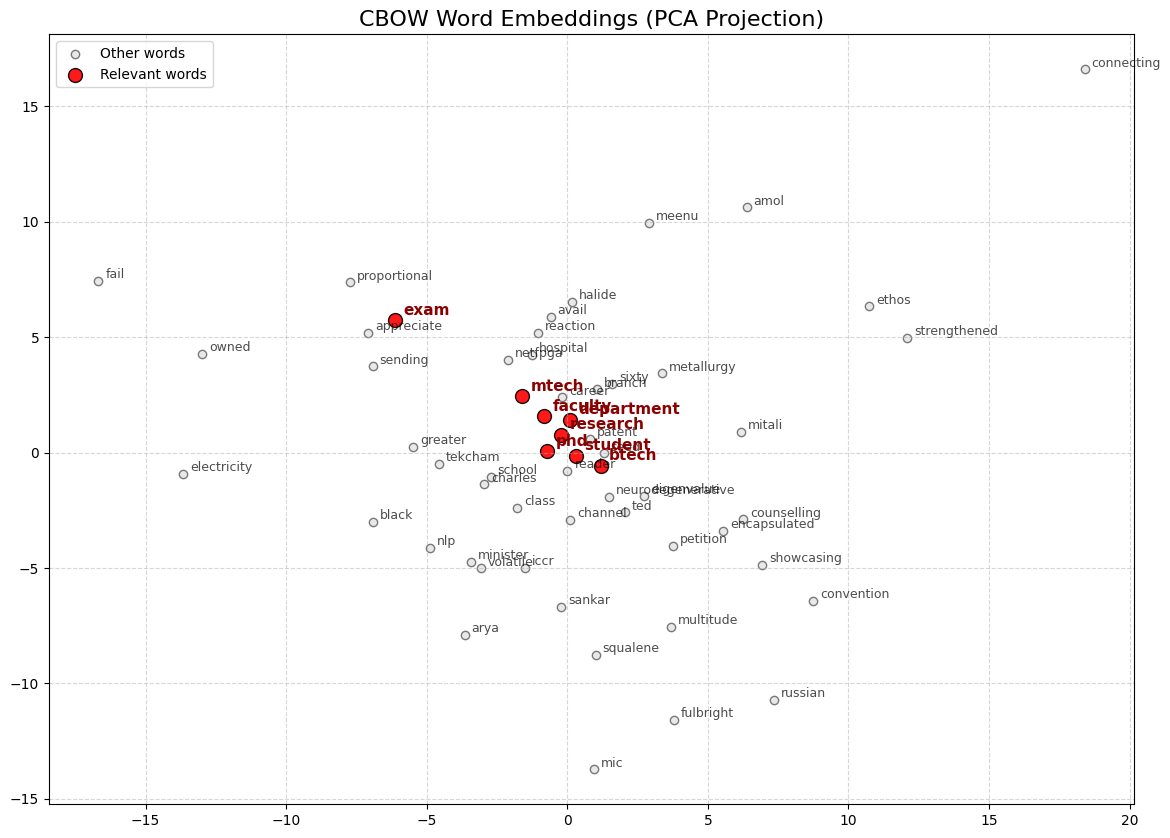

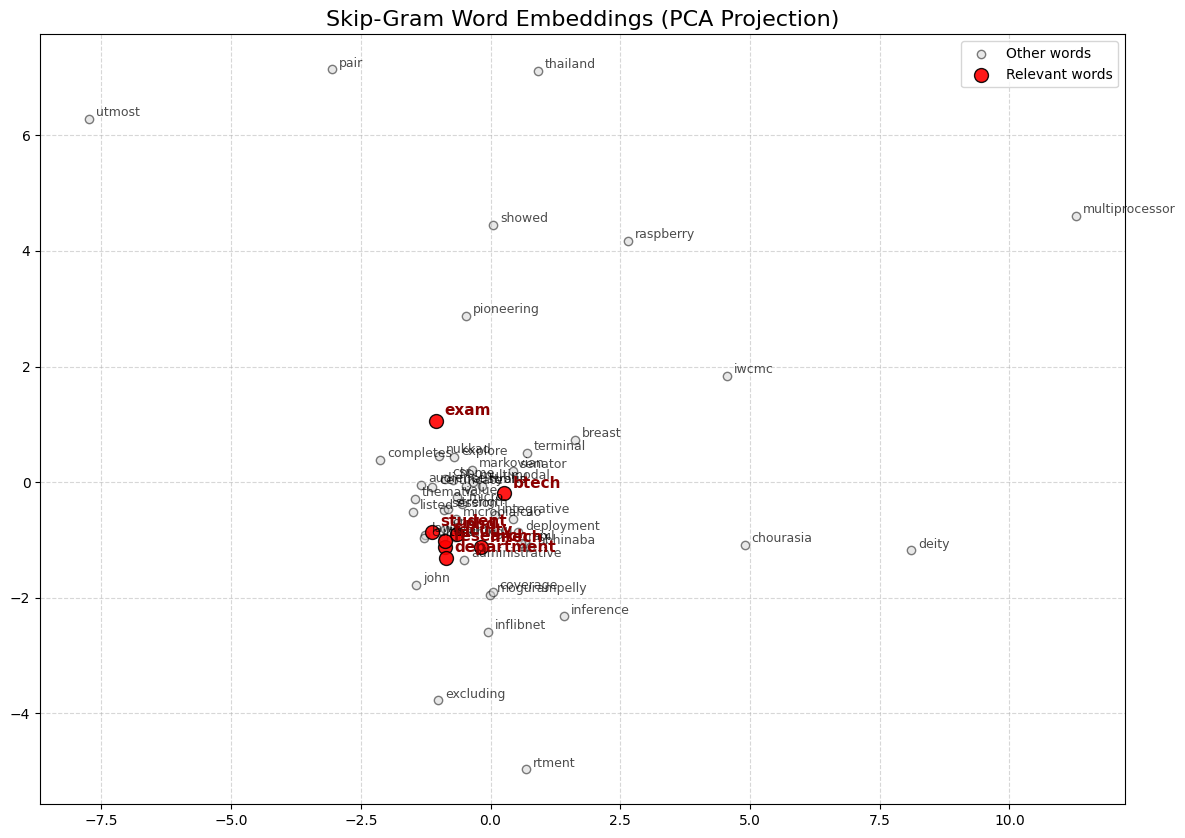

In [31]:
# Visualize selected embeddings with PCA

from sklearn.decomposition import PCA
import random

def plot_embeddings(embeddings, title):
    words_to_plot = random.sample(vocab, 50)
    for w in ['research', 'student', 'phd', 'exam', 'btech', 'mtech', 'faculty', 'department']:
        if w in vocab and w not in words_to_plot:
            words_to_plot.append(w)
            
    indices_to_plot = [word2idx[w] for w in words_to_plot]
    vectors_to_plot = embeddings[indices_to_plot]
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(vectors_to_plot)
    
    plt.figure(figsize=(14, 10))
    
    relevant_words = ['research', 'student', 'phd', 'exam', 'btech', 'mtech', 'faculty', 'department']
    relevant_indices = [i for i, word in enumerate(words_to_plot) if word in relevant_words]
    other_indices = [i for i, word in enumerate(words_to_plot) if word not in relevant_words]
    
    plt.scatter(
        pca_result[other_indices, 0],
        pca_result[other_indices, 1],
        alpha=0.5,
        color='lightgray',
        edgecolors='k',
        label='Other words'
    )
    
    plt.scatter(
        pca_result[relevant_indices, 0],
        pca_result[relevant_indices, 1],
        alpha=0.9,
        color='red',
        edgecolors='k',
        s=100,
        label='Relevant words'
    )
    
    for i, word in enumerate(words_to_plot):
        if word in relevant_words:
            plt.annotate(
                word,
                xy=(pca_result[i, 0], pca_result[i, 1]),
                xytext=(6, 4),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color='darkred'
            )
        else:
            plt.annotate(
                word,
                xy=(pca_result[i, 0], pca_result[i, 1]),
                xytext=(5, 2),
                textcoords='offset points',
                fontsize=9,
                alpha=0.7
            )
        
    plt.title(title, fontsize=16)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_embeddings(cbow_embeddings, "CBOW Word Embeddings (PCA Projection)")
plot_embeddings(sg_embeddings, "Skip-Gram Word Embeddings (PCA Projection)")
